<a href="https://colab.research.google.com/github/rhmau1/PCVK_26/blob/main/Modul2/Modul2-D1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
from google.colab import files
uploaded = files.upload()

Saving KTP_424385556.JPG to KTP_424385556.JPG


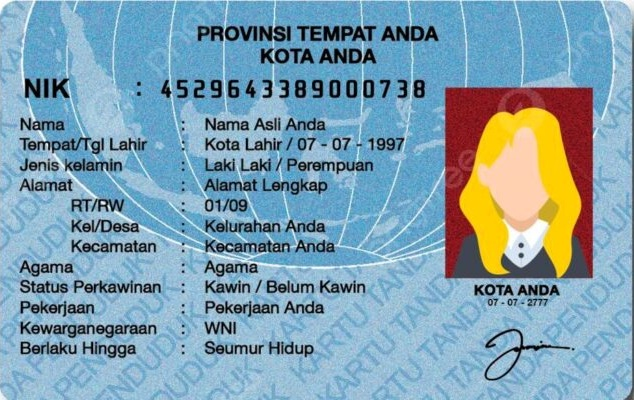

Resolusi gambar:  634 x 400


In [3]:
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
import matplotlib.pyplot as plt
import numpy as np

img = cv.imread("/content/drive/MyDrive/TI 3C RESOURCES /PCVK/Images/ktp.jpg")
cv2_imshow(img)
print("Resolusi gambar: ", img.shape[1], "x", img.shape[0])

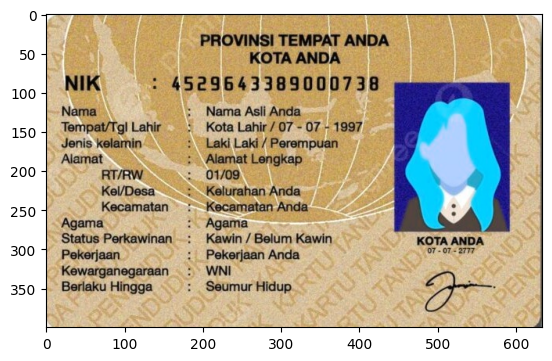

In [4]:
img = cv.imread("/content/drive/MyDrive/TI 3C RESOURCES /PCVK/Images/ktp.jpg")
plt.imshow(img)

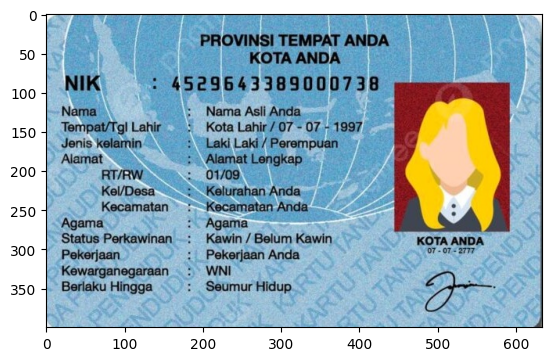

In [5]:
img2 = cv.cvtColor(img, cv.COLOR_BGR2RGB)
plt.imshow(img2)

# atau bisa juga dengan kode berikut
img = cv.imread("/content/drive/MyDrive/TI 3C RESOURCES /PCVK/Images/ktp.jpg")
plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
plt.show()

Text(0.5, 1.0, 'dengan cmap')

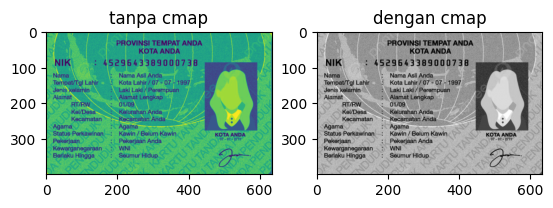

In [6]:
img_gray = cv.imread('/content/drive/MyDrive/TI 3C RESOURCES /PCVK/Images/ktp.jpg', cv.IMREAD_GRAYSCALE)

# tanpa cmap
plt.subplot(1, 2, 1)
plt.imshow(img_gray)
plt.title('tanpa cmap')

# dengan cmap
plt.subplot(1, 2, 2)
plt.imshow(img_gray, cmap='gray')
plt.title('dengan cmap')


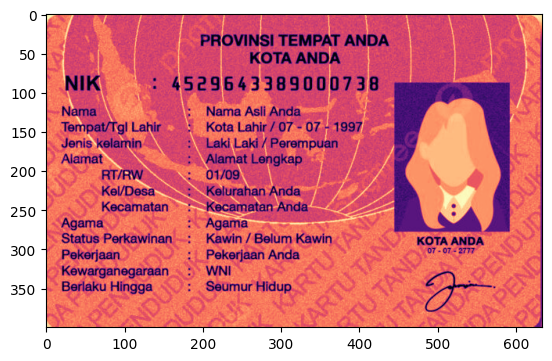

In [7]:
plt.imshow(img_gray, cmap="magma")

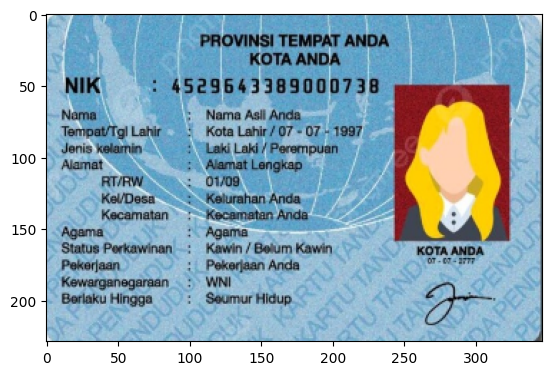

In [8]:
imgRGB = cv.cvtColor(img, cv.COLOR_BGR2RGB)
img_output = cv.resize(imgRGB, (347, 229))
plt.imshow(img_output)

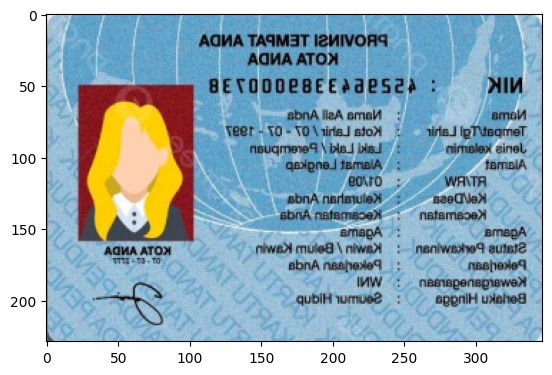

In [9]:
imgFLip = cv.flip(img_output, 1)
plt.imshow(imgFLip)

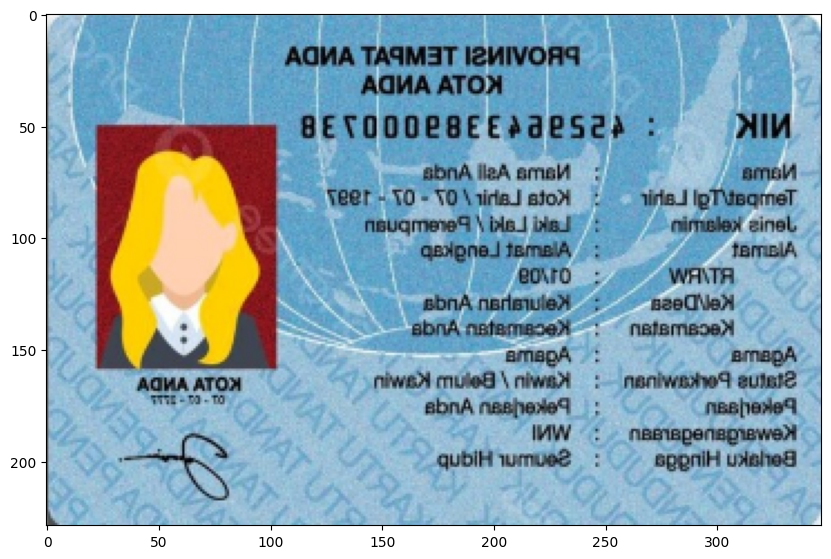

In [10]:
imgFLip = cv.flip(img_output, 1)
# tampilkan canvas lebih besar
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111)
ax.imshow(imgFLip)

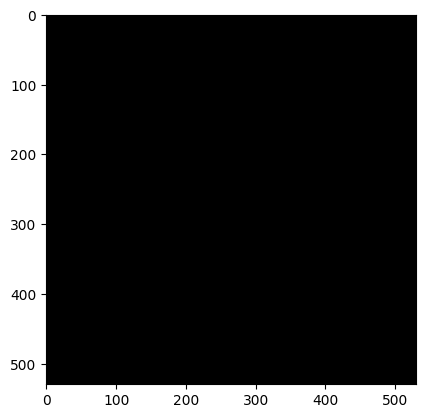

In [11]:
black_img = np.zeros(shape=(530, 530, 3), dtype=np.int16)
plt.imshow(black_img)

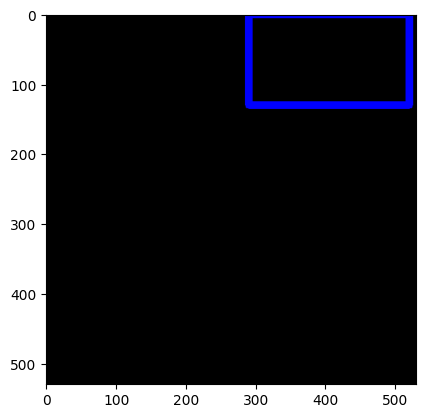

In [12]:
# menambahkan bentuk persegi panjang
cv.rectangle(black_img, pt1=(290, 0), pt2=(520, 130), color=(0, 0, 255), thickness=10)
plt.imshow(black_img)

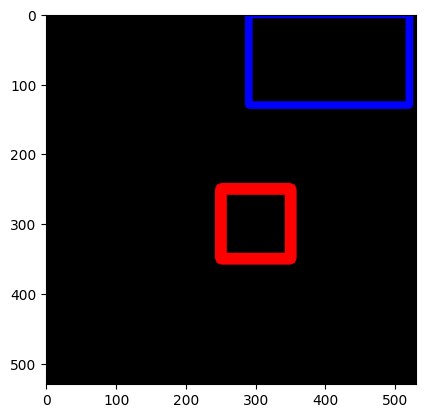

In [13]:
# menambahkan bentuk persegi
cv.rectangle(black_img, pt1=(250, 250), pt2=(350, 350), color=(255, 0, 0), thickness=15)
plt.imshow(black_img)

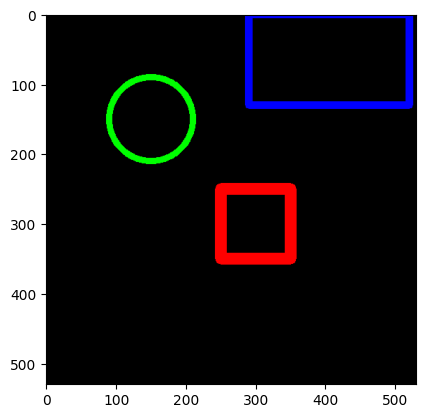

In [14]:
# menambahkan bulat lingkaran
cv.circle(black_img, center=(150, 150), radius=60, color=(0, 255, 0), thickness=8)
plt.imshow(black_img)

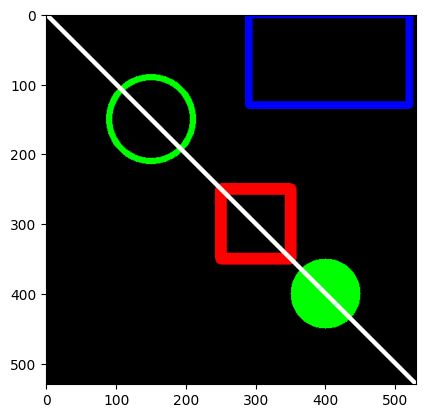

In [15]:
# menambahkan lingkaran berwarna dan garis
cv.circle(black_img, center=(400, 400), radius=50, color=(0, 255, 0), thickness=-1)
cv.line(black_img, pt1=(0, 0), pt2=(530, 530), color=(255, 255, 255), thickness=5)
plt.imshow(black_img)

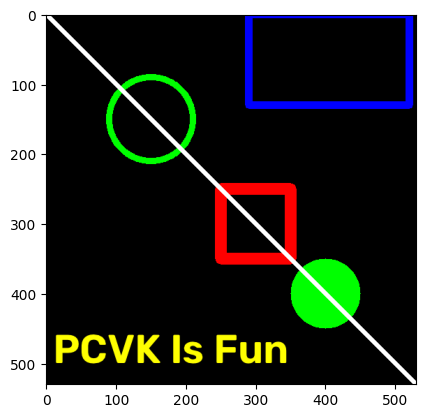

In [18]:
# menambahkan text dengan font yang sudah ditentukan
font = cv.FONT_HERSHEY_SIMPLEX
# Convert black_img to uint8 type before using putText
black_img = black_img.astype(np.uint8)
cv.putText(black_img, text='PCVK Is Fun', org=(10, 500), fontFace=font, fontScale=2, color=(255, 255, 0), thickness=3, lineType=cv.LINE_AA)
plt.imshow(black_img)

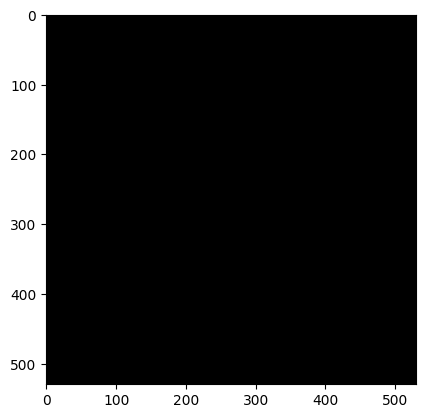

In [19]:
black_img2 = np.zeros(shape=(530, 530, 3), dtype=np.int32)
plt.imshow(black_img2)

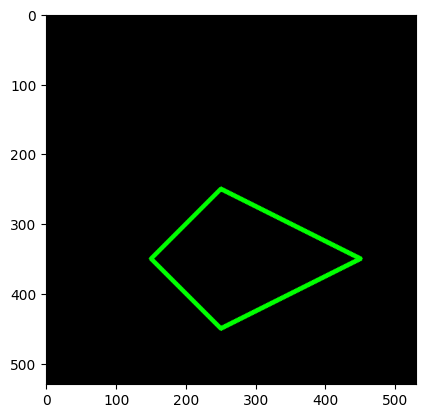

In [20]:
# inisiasi numpy array dgn tipe data int32
vertices = np.array([[150,350],[250,250], [450,350],[250,450]],dtype=np.int32)
pts = vertices.reshape((-1,1,2)) #nilai 2 untuk menunjukkan bahwa tiap titik dibuat 3 channel yang mewakili R,G,B

# menambahkan polyline
cv.polylines(black_img2, [pts], isClosed=True, color=(0,255,0), thickness=5)
plt.imshow(black_img2)

# PERTANYAAN PRAKTIKUM
1. Tampilkan satu citra bebas menggunakan cv2_imshow() dan plt.imshow() tanpa konversi warna apa pun. Mengapa hasilnya berbeda? Buktikan dengan mencetak nilai satu piksel yang sama dari kedua cara pembacaan tersebut.
- menggunakan cv2_imshow hasilnya tampil dengan format warna BGR, sedangkan menggunakan plt.imshow tampil dengan format warna RGB
2. Buat kanvas hitam berukuran sama dengan tipe data int16 dan int32. Bandingkan dtype, min(), max(), dan nbytes keduanya. Apakah tampilannya berbeda? Apakah ukuran memorinya berbeda? Jelaskan alasannya.
- secara visual tampilannya sama saja, min dan max juga sama keduanya bernilai 0 karena warna hitam direpresentasikan jadi nilai 0 sehingga keduanya sama-sama 0
- secara ukuran memori berbeda karena int16 hanya menggunakan 16 bit sedangkan int32 menggunakan 32 bit
3. Apa kegunaan baris from google.colab.patches import cv2_imshow, dan mengapa cv2.imshow() bawaan OpenCV tidak dapat dipakai di Google Colab?
- Fungsi cv2.imshow() bawaan OpenCV mencoba memanggil window GUI (jendela grafis) dari sistem operasi host (seperti X11/Wayland di Linux atau Windows GUI). Karena Google Colab berjalan di lingkungan cloud berbasis browser web, sistem tidak memiliki antarmuka grafis untuk menampilkan jendela pop-up tersebut, sehingga memanggil cv2.imshow() akan membuat kernel error atau crash.
Baris from google.colab.patches import cv2_imshow digunakan untuk mengimpor fungsi khusus yang dibuat oleh Google untuk me-render array citra langsung menjadi gambar (PNG) di dalam sel output browser.
4. Citra yang dibaca dengan skimage.io.imread() ditampilkan berdampingan dengan hasil cv2.cvtColor(img, cv2.COLOR_BGR2RGB) atas citra yang sama. Manakah yang menampilkan warna sebenarnya, dan manakah yang kanalnya tertukar? Buktikan dengan nilai piksel, bukan dengan pengamatan visual saja.
- Jika keduanya ditampilkan menggunakan plt.imshow(), keduanya menampilkan warna yang sebenarnya dan tidak ada kanal yang tertukar.
Alasannya: skimage.io.imread() secara default membaca gambar langsung dalam format RGB. Sementara itu, cv2.cvtColor(img, cv2.COLOR_BGR2RGB) mengonversi gambar OpenCV (yang awalnya BGR) menjadi RGB. Karena keduanya sudah dalam format RGB, plt.imshow() akan membacanya dengan tepat.

5. Setelah citra ditampilkan dengan figsize yang jauh lebih besar, apakah nilai img.shape ikut berubah? Jelaskan perbedaan antara mengubah ukuran citra dan mengubah ukuran tampilan.
- Apakah nilai img.shape berubah? Tidak.
 Penjelasan: Mengubah figsize pada Matplotlib hanya mengubah ukuran tampilan kanvas (display size) saat gambar dirender di layar Anda, diukur dalam satuan inci. Sedangkan img.shape adalah dimensi matriks data (jumlah baris piksel, kolom piksel, dan kanal warna) di dalam memori komputer.

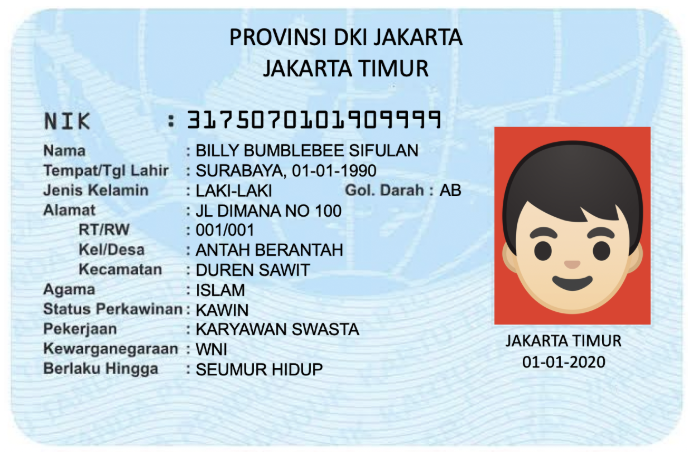

In [21]:
ktpku = cv.imread("/content/drive/MyDrive/TI 3C RESOURCES /PCVK/Images/ktp1.jpg")
# jadi awalnya tuh ktp1.jpg format RGB terus disimpan sama cv.imread ke memori pake format BGR
cv2_imshow(ktpku)
# nah di cv2_imshow ini expect data yg masuk formatnya BGR juga, trs waktu dikirimkan ktpku yg dimana formatnya udh diubah jadi BGR jadi dia bisa tampil ke warna yang normal

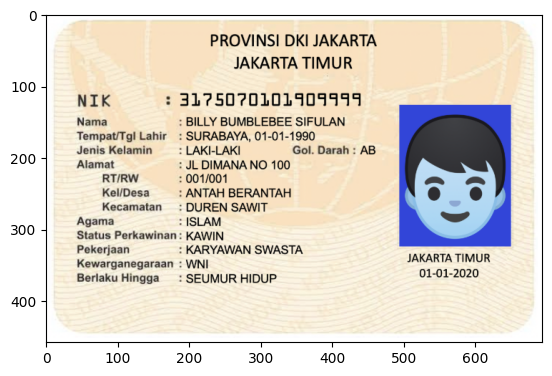

In [22]:
plt.imshow(ktpku)
# ktpku tadi dibacanya pake cv.imread jadi formatnya BGR, sedangkan di plt.imshow expectnya datanya selalu RGB, jadi ketika ditampilkan warnanya tertukar

[ 55 104   0]


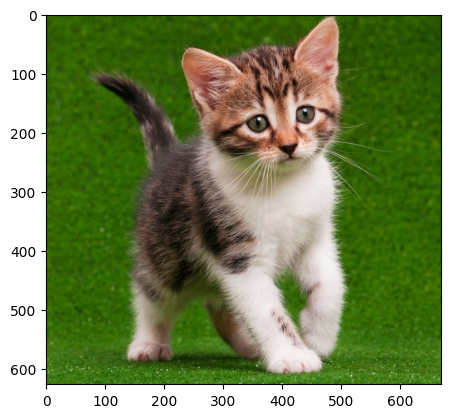

In [23]:
img_skimage = io.imread("/content/drive/MyDrive/TI 3C RESOURCES /PCVK/Images/kitten01.jpg")
print(img_skimage[0,0])
plt.imshow(img_skimage)

[ 55 104   0]


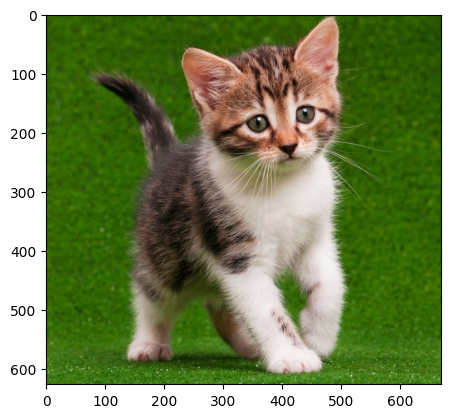

In [24]:
img_cv2 = cv.imread("/content/drive/MyDrive/TI 3C RESOURCES /PCVK/Images/kitten01.jpg")
img_cv2_rgb = cv.cvtColor(img_cv2, cv.COLOR_BGR2RGB)
print(img_cv2_rgb[0,0])
plt.imshow(img_cv2_rgb)

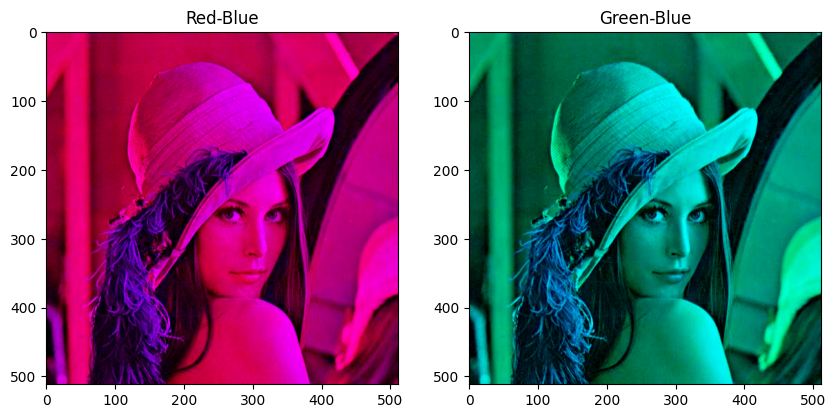

In [28]:
# Tampilkan image dalam channel Red-Blue dan Green-Blue saja!
img = cv.imread("/content/drive/MyDrive/TI 3C RESOURCES /PCVK/Images/lena.jpg")
# Pisahkan channel
b,g,r = cv.split(img)

# Red-Blue (Green di-nolkan)
rb = cv.merge([b, np.zeros_like(g), r])

# Green-Blue (Red di-nolkan)
gb = cv.merge([b, g, np.zeros_like(r)])

# Tampilkan
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(cv.cvtColor(rb, cv.COLOR_BGR2RGB))
plt.title("Red-Blue")

plt.subplot(1,2,2)
plt.imshow(cv.cvtColor(gb, cv.COLOR_BGR2RGB))
plt.title("Green-Blue")
plt.show()

Text(0.5, 1.0, 'Vertikal')

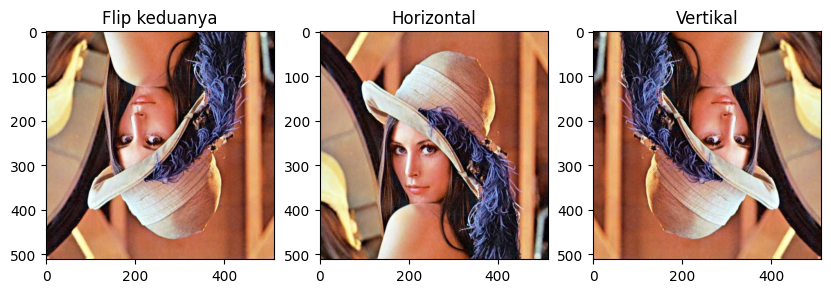

In [29]:
# Tampilkan citra dalam tiga bentuk pencerminan: vertikal, horizontal, dan keduanya, dalam satu figure berisi tiga subplot yang masing-masing diberi label.
plt.figure(figsize=(10,5))
plt.subplot(1,3,1)
imgFlipDouble = cv.flip(img, -1)
plt.imshow(cv.cvtColor(imgFlipDouble, cv.COLOR_BGR2RGB))
plt.title("Flip keduanya")

plt.subplot(1,3,2)
imgHorizontal = cv.flip(img,1)
plt.imshow(cv.cvtColor(imgHorizontal, cv.COLOR_BGR2RGB))
plt.title("Horizontal")

plt.subplot(1,3,3)
imgVertical = cv.flip(img,0)
plt.imshow(cv.cvtColor(imgVertical, cv.COLOR_BGR2RGB))
plt.title("Vertikal")

Saving almet.jpg to almet.jpg


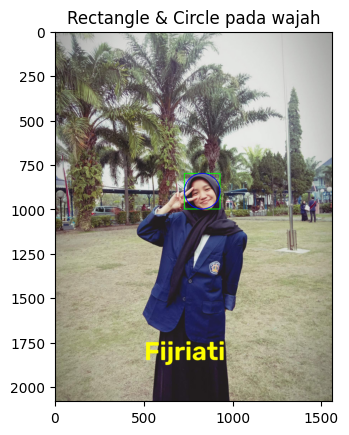

In [27]:
# Buat rectangle dan circle pada bagian wajah dari image foto s anda saat beraktifitas (bukan pasfoto).
uploaded = files.upload()
img = cv.imread('almet.jpg')

foto_wajah = img.copy()

# Rectangle pada wajah
cv.rectangle(foto_wajah, pt1=(725,800), pt2=(925,1000), color=(0,255,0), thickness=3)

# Circle di wajah
cv.circle(foto_wajah, center=(825,900), radius=100, color=(255,0,0), thickness=3)

font = cv.FONT_HERSHEY_SIMPLEX
cv.putText(foto_wajah, text='Fijriati', org=(500,1850), fontFace=font,
           fontScale=5, color=(0,255,255), thickness=8, lineType=cv.LINE_AA)
plt.imshow(cv.cvtColor(foto_wajah, cv.COLOR_BGR2RGB))
plt.title("Rectangle & Circle pada wajah")

plt.show()


In [31]:
# TUGAS PRAKTIKUM - Analisa
# Pertanyaan: Apakah mengecilkan lalu membesarkan citra mengubah rata-rata intensitasnya?

def analyze_intensity_change(image):
    # 1. Hitung rata-rata awal
    initial_mean = np.mean(image)

    # 2. Resize: Kecilkan menjadi 10% lalu besarkan kembali ke ukuran asli
    h, w = image.shape[:2]
    small = cv.resize(image, (w // 10, h // 10), interpolation=cv.INTER_AREA)
    restored = cv.resize(small, (w, h), interpolation=cv.INTER_LINEAR)

    # 3. Hitung rata-rata akhir
    final_mean = np.mean(restored)
    diff = abs(initial_mean - final_mean)

    print(f"Rata-rata Intensitas Awal: {initial_mean:.4f}")
    print(f"Rata-rata Intensitas Setelah Resize: {final_mean:.4f}")
    print(f"Selisih: {diff:.4f}")

    return diff

# Menjalankan analisa menggunakan citra 'img' yang sudah ada
if 'img' in locals():
    analyze_intensity_change(img)

# Kesimpulan:
# Ya, terdapat sedikit perubahan rata-rata intensitas karena proses interpolasi
# saat downsampling (INTER_AREA) dan upsampling (INTER_LINEAR) membuang
# serta mengestimasi informasi piksel, meskipun selisihnya seringkali sangat kecil.

Rata-rata Intensitas Awal: 119.7325
Rata-rata Intensitas Setelah Resize: 119.6009
Selisih: 0.1316


SILAKAN UNGGAH GAMBAR (Portrait, Landscape, atau Square):


Saving landscape.jpg to landscape.jpg


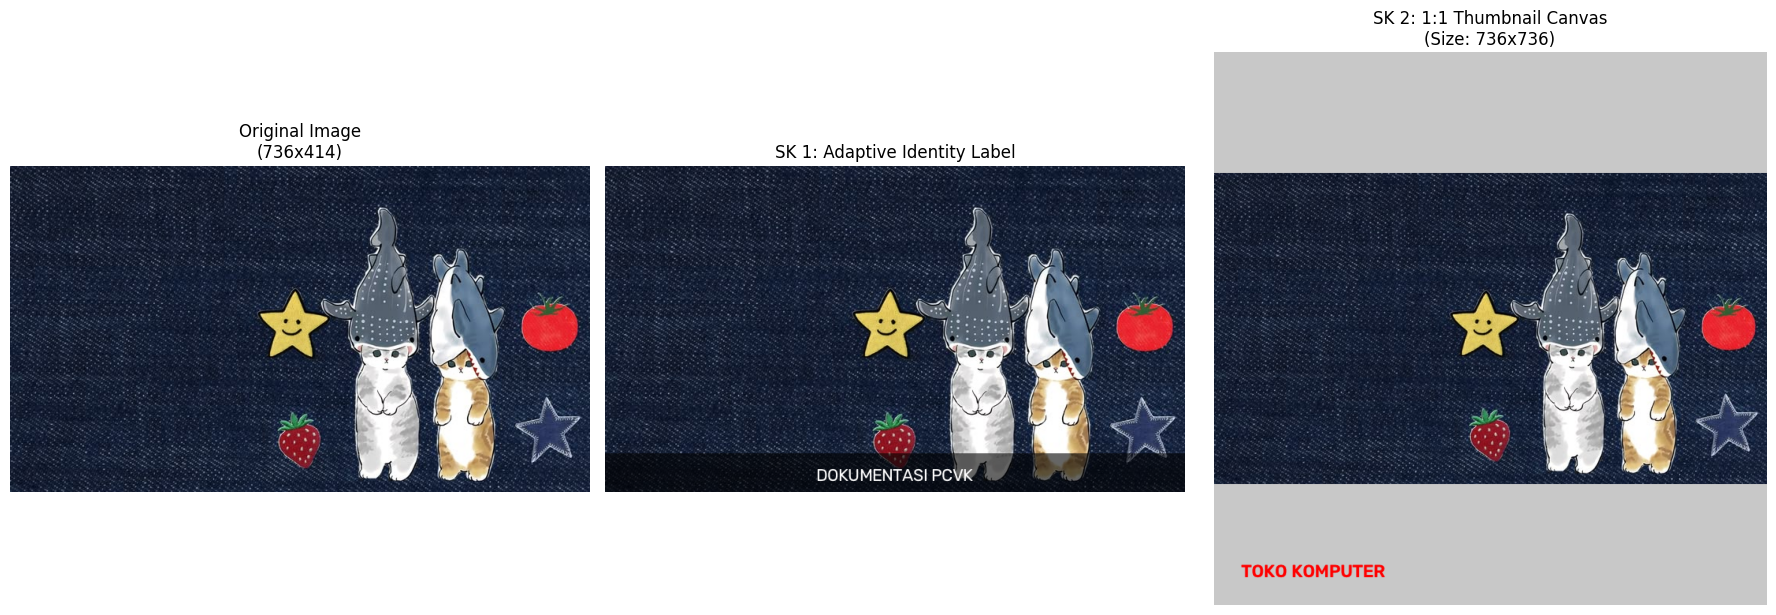

In [2]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

def apply_adaptive_label(image, text="DOKUMENTASI PCVK"):
    # Mendapatkan dimensi gambar
    h, w = image.shape[:2]
    img_res = image.copy()

    # LOGIKA ADAPTIF (SK 1):
    # Menghitung parameter berdasarkan persentase tinggi gambar (h)
    bar_h = int(h * 0.12)       # Tinggi bar 12% dari tinggi gambar
    f_scale = h / 550.0         # Skala font menyesuaikan tinggi
    thick = max(1, int(h / 250)) # Ketebalan garis menyesuaikan tinggi

    # Membuat bar semi-transparan menggunakan overlay dan addWeighted
    overlay = img_res.copy()
    cv.rectangle(overlay, (0, h - bar_h), (w, h), (0, 0, 0), -1)
    cv.addWeighted(overlay, 0.6, img_res, 0.4, 0, img_res)

    # Menentukan posisi teks di tengah bar secara otomatis
    font = cv.FONT_HERSHEY_SIMPLEX
    t_size = cv.getTextSize(text, font, f_scale, thick)[0]
    t_x = (w - t_size[0]) // 2
    t_y = h - (bar_h // 2) + (t_size[1] // 2)

    cv.putText(img_res, text, (t_x, t_y), font, f_scale, (255, 255, 255), thick, cv.LINE_AA)
    return img_res

def create_square_thumbnail(image, store_name="TOKO KOMPUTER"):
    h, w = image.shape[:2]
    side = max(h, w)

    # LOGIKA ADAPTIF (SK 2):
    # 1. Membuat kanvas persegi (1:1) dengan NumPy
    canvas = np.full((side, side, 3), 200, dtype=np.uint8) # Warna background abu-abu terang

    # 2. Menghitung offset pengirisan agar gambar berada tepat di tengah
    x_off = (side - w) // 2
    y_off = (side - h) // 2

    # 3. Menempelkan citra asli ke kanvas menggunakan pengirisan (Slicing)
    canvas[y_off:y_off+h, x_off:x_off+w] = image

    # 4. Menambahkan logo/nama toko yang proporsional terhadap ukuran kanvas
    f_scale = side / 900.0
    thick = max(1, int(side / 450))
    # Posisi logo di pojok kiri bawah secara adaptif
    cv.putText(canvas, store_name, (int(side*0.05), int(side*0.95)),
               cv.FONT_HERSHEY_TRIPLEX, f_scale, (0, 0, 255), thick, cv.LINE_AA)

    return canvas

# Meminta user mengunggah file untuk menunjukkan perbedaan adaptasi
print("SILAKAN UNGGAH GAMBAR (Portrait, Landscape, atau Square):")
uploaded = files.upload()

for fn in uploaded.keys():
    img_input = cv.imread(fn)
    if img_input is None: continue

    h_orig, w_orig = img_input.shape[:2]

    # Proses fungsi
    sk1_result = apply_adaptive_label(img_input)
    sk2_result = create_square_thumbnail(img_input)

    # Visualisasi perbandingan
    plt.figure(figsize=(18, 6))

    plt.subplot(1, 3, 1)
    plt.imshow(cv.cvtColor(img_input, cv.COLOR_BGR2RGB))
    plt.title(f"Original Image\n({w_orig}x{h_orig})")
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(cv.cvtColor(sk1_result, cv.COLOR_BGR2RGB))
    plt.title("SK 1: Adaptive Identity Label")
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(cv.cvtColor(sk2_result, cv.COLOR_BGR2RGB))
    plt.title(f"SK 2: 1:1 Thumbnail Canvas\n(Size: {sk2_result.shape[0]}x{sk2_result.shape[1]})")
    plt.axis('off')

    plt.tight_layout()
    plt.show()